### 02 - Linear Model
Goal:
Predict continuous hourly electricity demand by drawing a mathematically "straight line" through our time patterns and weather conditions.
Why did we use it?
It serves as our fundamental baseline.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

print(f'Shape: {df.shape}')
df.head(3)

os.makedirs('../outputs/figures/02_lm', exist_ok=True)

Shape: (35045, 19)


#### 1. Train / Test Split

In [2]:
train = df[df.index.year < 2025].copy()
test  = df[df.index.year == 2025].copy()

print(f'Train: {len(train):,} rows  ({train.index.year.min()}–{train.index.year.max()})')
print(f'Test:  {len(test):,} rows  ({test.index.year.min()}–{test.index.year.max()})')
print(f'Train share: {len(train)/len(df)*100:.1f}%')

Train: 26,286 rows  (2022–2024)
Test:  8,759 rows  (2025–2025)
Train share: 75.0%


#### 2. OLS Model

All predictors included. Season as dummies (reference = autumn), with interactions T:hour_cos and T:is_weekend.

In [3]:
formula = (
    'demand_log ~ '
    'T + Hr + StrGlo + RainDur + WVv + p + '
    'hour_sin + hour_cos + month_sin + month_cos + '
    'is_weekend + C(season) + '
    'T:hour_cos + T:is_weekend'
)

# statsmodels drops NaN rows automatically
model = smf.ols(formula, data=train).fit()

print(f'Train R²      = {model.rsquared:.4f}')
print(f'Train Adj. R² = {model.rsquared_adj:.4f}')
print(f'AIC     = {model.aic:.1f}')
print(f'N       = {int(model.nobs):,}')

Train R²      = 0.7855
Train Adj. R² = 0.7854
AIC     = -46792.0
N       = 26,260


In [4]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             demand_log   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     6006.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        23:22:08   Log-Likelihood:                 23413.
No. Observations:               26260   AIC:                        -4.679e+04
Df Residuals:                   26243   BIC:                        -4.665e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              10.7927      0.082    130.960      0.000      10.631      10.954
C(season)[T.spring]    -0.0291      0.004     -6.873      0.000      -0.037      -0.021
C(season)[T.summer]     0.0435      0.003     13.449      0.000       0.037       0.050
C(season)[T.winter]    -0.0229      0.003     -7.101      0.000      -0.029      -0.017
T                      -0.0025      0.000    -12.880      0.000      -0.003      -0.002
Hr                      0.0001   6.31e-05      1.912      0.056   -3.03e-06       0.000
StrGlo              -5.766e-05   5.44e-06    -10.598      0.000   -6.83e-05    -4.7e-05
RainDur                 0.0002    4.4e-05      3.609      0.000    7.26e-05       0.000
WVv                    -0.0029      0.001     -4.926      0.000      -0.004      -0.002
p                       0.0005   8.47e-05      5.903      0.000       0.000       0.001
hour_sin               -0.1564      0.001   -156.948      0.000      -0.158      -0.154
hour_cos               -0.2265      0.002   -131.556      0.000      -0.230      -0.223
month_sin               0.0296      0.002     12.810      0.000       0.025       0.034
month_cos               0.0329      0.002     13.337      0.000       0.028       0.038
is_weekend             -0.1175      0.003    -45.282      0.000      -0.123      -0.112
T:hour_cos              0.0011      0.000      8.070      0.000       0.001       0.001
T:is_weekend           -0.0025      0.000    -14.434      0.000      -0.003      -0.002
==============================================================================
Omnibus:                      260.696   Durbin-Watson:                   0.220
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              264.044
Skew:                          -0.236   Prob(JB):                     4.61e-58
Kurtosis:                       2.863   Cond. No.                     1.32e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.32e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 3. Diagnostics

#### Residual Q-Q plot

The Q-Q plot below tests the normality of the OLS residuals, a core assumption of the linear model. This is distinct from the Q-Q plot in the EDA, which examined the distribution of the raw demand variable. If the residual points deviate from the diagonal line (especially in the tails), the normality assumption is violated and inference (p-values, confidence intervals) may be unreliable.

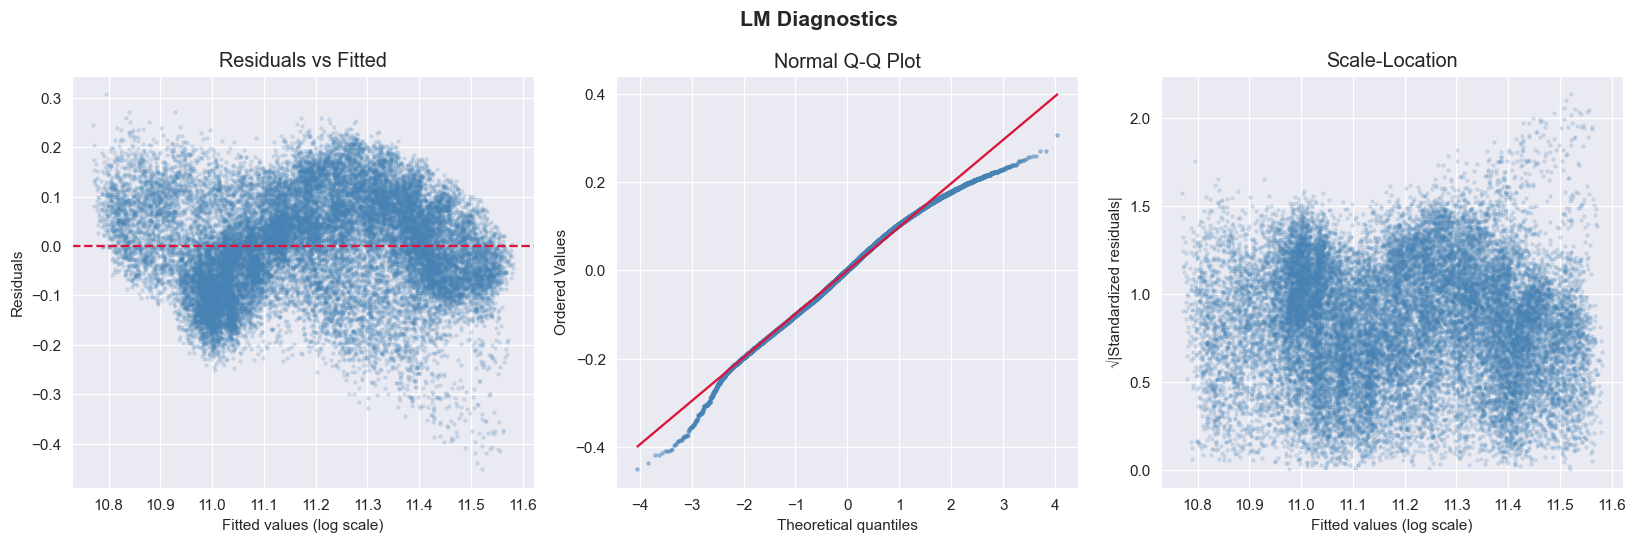

In [5]:
fitted    = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# residuals vs fitted
axes[0].scatter(fitted, residuals, alpha=0.15, s=4, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[1].get_lines()[1].set(color='crimson')

# scale-location
std_resid = model.get_influence().resid_studentized_internal
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.15, s=4, color='steelblue')
axes[2].set_xlabel('Fitted values (log scale)')
axes[2].set_ylabel('√|Standardized residuals|')
axes[2].set_title('Scale-Location')

fig.suptitle('LM Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_lm/02_07_lm_diagnostics.png', bbox_inches='tight')
plt.show()

#### 4. Coefficient Interpretation

In [6]:
coef = pd.DataFrame({
    'estimate': model.params,
    'std_err':  model.bse,
    'p_value':  model.pvalues
}).round(5)
coef['significant'] = coef['p_value'] < 0.05
coef = coef.sort_values('p_value')
coef

,estimate,std_err,p_value,significant
Intercept,10.79271,0.08241,0.00000,True
is_weekend,-0.11750,0.00259,0.00000,True
month_cos,0.03287,0.00246,0.00000,True
month_sin,0.02962,0.00231,0.00000,True
hour_cos,-0.22645,0.00172,0.00000,True
hour_sin,-0.15635,0.00100,0.00000,True
p,0.00050,0.00008,0.00000,True
T:hour_cos,0.00110,0.00014,0.00000,True
WVv,-0.00291,0.00059,0.00000,True
StrGlo,-0.00006,0.00001,0.00000,True


hour_sin/cos and month_sin/cos carry most of the weight. Temperature is negative: colder = higher demand. T:hour_cos shows the effect changes by time of day. is_weekend lowers demand. Hr is the only predictor not significant at 5%.

### Cyclic encoding limitation

A single sine/cosine pair (one harmonic) can only represent a unimodal daily pattern, one peak and one trough per 24 hours. Zurich's electricity demand however follows a bimodal daily curve, with a morning peak (~8–9h) and an evening peak (~19–20h). A single harmonic cannot fit both peaks simultaneously. Higher-order Fourier terms (e.g. a second sine/cosine pair at double frequency) or treating hour as a categorical variable would capture this better.

#### 5. Test Set Predictions

In [7]:
#Drop rows before predicting
pred_cols = ['T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
             'is_weekend', 'season', 'demand_log']

test_clean = test.dropna(subset=pred_cols)

print(f'Test rows total:   {len(test):,}')
print(f'Test rows kept:    {len(test_clean):,}')
print(f'Test rows dropped: {len(test) - len(test_clean):,}')

y_pred_log = model.predict(test_clean)
y_pred     = np.exp(y_pred_log)
y_actual   = np.exp(test_clean['demand_log'])

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)
test_r2 = r2_score(y_actual, y_pred)

print(f'RMSE: {rmse:,.1f} kW  ({rmse / y_actual.mean() * 100:.1f}% of mean demand)')
print(f'MAE: {mae:,.1f} kW  ({mae  / y_actual.mean() * 100:.1f}% of mean demand)')
print(f'Test R²: {test_r2:.4f}')

Test rows total:   8,759
Test rows kept:    8,748
Test rows dropped: 11
RMSE: 7,623.7 kW  (10.3% of mean demand)
MAE: 6,125.8 kW  (8.3% of mean demand)
Test R²: 0.7517


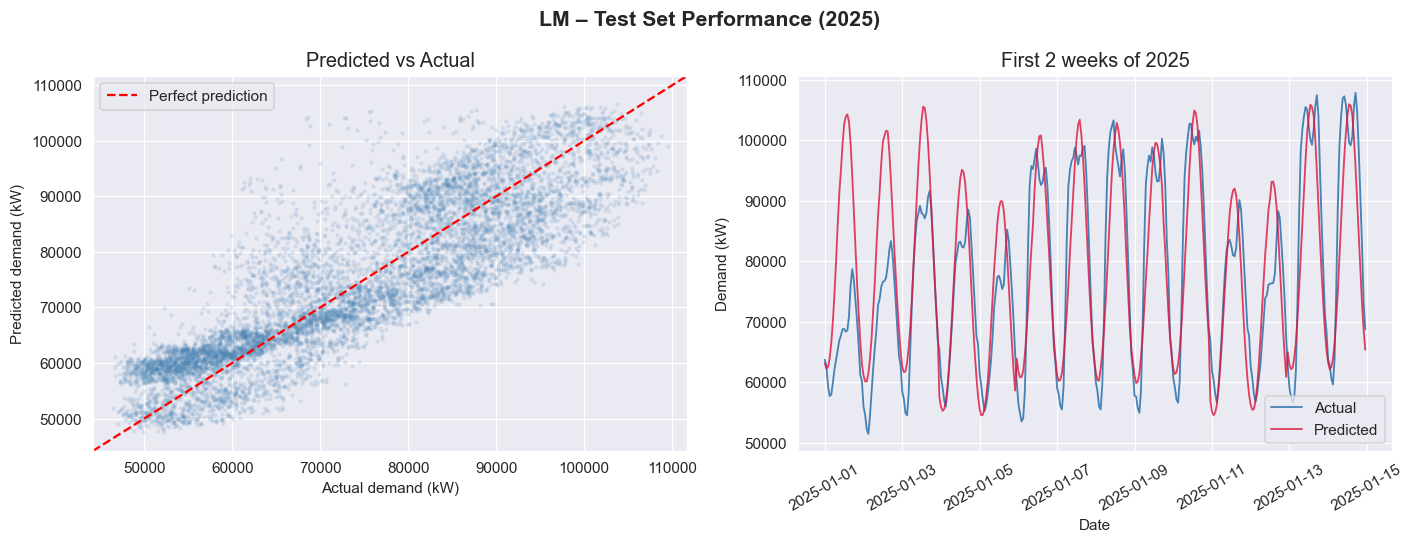

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter: predicted vs actual
lim = [y_actual.min() * 0.95, y_actual.max() * 1.02]
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual demand (kW)')
axes[0].set_ylabel('Predicted demand (kW)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# time series: first 2 weeks of 2025
sample = test_clean.iloc[:24*14]
axes[1].plot(sample.index, np.exp(sample['demand_log']), lw=1.2,
             label='Actual', color='steelblue')
axes[1].plot(sample.index, np.exp(model.predict(sample)), lw=1.2,
             label='Predicted', color='crimson', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kW)')
axes[1].set_title('First 2 weeks of 2025')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('LM – Test Set Performance (2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_lm/02_08_lm_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### 6. Save Metrics

In [9]:
new_row = pd.DataFrame([{
    'model':     'LM',
    'rmse':      round(rmse, 1),
    'mae':       round(mae, 1),
    'r2_train':  round(model.rsquared, 4),
    'r2_test': round(test_r2, 4),
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'LM']   # overwrite if re-run
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row)

          model      rmse       mae  r2_train     auc  r2_test
0   GLM_Poisson     2.611     1.427    0.7259     NaN      NaN
1  GLM_Binomial       NaN       NaN    0.5254  0.9593      NaN
2           GAM  3861.300  2595.700    0.9372     NaN   0.9392
3   NN (128,64)  2660.600  2038.200    0.9752     NaN   0.9710
4           SVM   881.000   653.700    0.9974     NaN   0.9967
5            LM  7623.700  6125.800    0.7855     NaN   0.7517
